In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from lib.models import RegNetv3
from lib.data.dataloading import load_nursing_5_class
from lib.modules import optimization_loop_multi_class, evaluate_loop
import torch
from torch import nn
import matplotlib.pyplot as plt
import json
import numpy as np
from lib.utils import sample_regnet
from tqdm import tqdm

In [ ]:
CONFIG = {
    'WINDOW_SIZE':2001,
    'NURSING_STRIDE': 2001 // 16,
    'BATCH_SIZE': 512,
    'LEARNING_RATE': 3e-4,
    'TEST_SIZE': 0.25,
    'DEVICE': 'cuda:0',
    'DEPTHI': [1, 1, 2, 2],
    'WIDTHI': [16, 56, 120, 248],
}

In [ ]:
nurses = list(set(range(11,71)) - set([37, 46, 70, 39, 22, 13]))
len(nurses)

In [129]:
import pandas as pd
from pathlib import Path
import json

df = pd.DataFrame(columns=['n', 'd', 'w', 'nparams', 'best_f1', 'best_loss'])

for model_dir in Path('dev/dataaug').iterdir():
    config = json.load(open(model_dir / 'config.json'))
    info = json.load(open(model_dir / 'info.json'))
    nparams = sum([param.numel() for param in RegNetv3(CONFIG=config).parameters()])
    df.loc[len(df)] = {
        'n': int(config['N']),
        'd': config['DEPTHI'],
        'w': config['WIDTHI'],
        'nparams': nparams,
        'best_f1': sum(info['f1']) / len(info['f1']),
        'best_loss': info['loss']
    }
for model_dir in Path('dev/dataaug_small').iterdir():
    config = json.load(open(model_dir / 'config.json'))
    info = json.load(open(model_dir / 'info.json'))
    nparams = sum([param.numel() for param in RegNetv3(CONFIG=config).parameters()])
    df.loc[len(df)] = {
        'n': int(config['N']),
        'd': config['DEPTHI'],
        'w': config['WIDTHI'],
        'nparams': nparams,
        'best_f1': sum(info['f1']) / len(info['f1']),
        'best_loss': info['loss']
    }

In [132]:
df[df.n==30].sort_values('best_f1', ascending=False).head(20)

,n,d,w,nparams,best_f1,best_loss
103,30,"[1, 1, 3]","[16, 56, 160]",197527,0.692716,0.751438
67,30,"[2, 9, 9]","[40, 112, 312]",2812895,0.690624,1.495684
83,30,"[1, 2, 3]","[8, 40, 88]",69823,0.683192,0.791065
147,30,"[1, 3, 2]","[40, 88, 192]",247855,0.678384,0.826394
154,30,"[1, 1, 1]","[40, 96, 200]",100999,0.675096,0.797893
112,30,"[1, 3, 5, 2]","[56, 120, 280, 640]",3153391,0.667838,0.846089
135,30,"[1, 1, 1, 4]","[16, 32, 72, 152]",267655,0.661268,0.829111
158,30,"[1, 2]","[16, 48]",13319,0.659421,0.855890
122,30,"[1, 4, 9, 6]","[16, 32, 80, 184]",747943,0.658900,0.902891
130,30,"[3, 7, 1]","[48, 96, 216]",292911,0.656167,0.917163


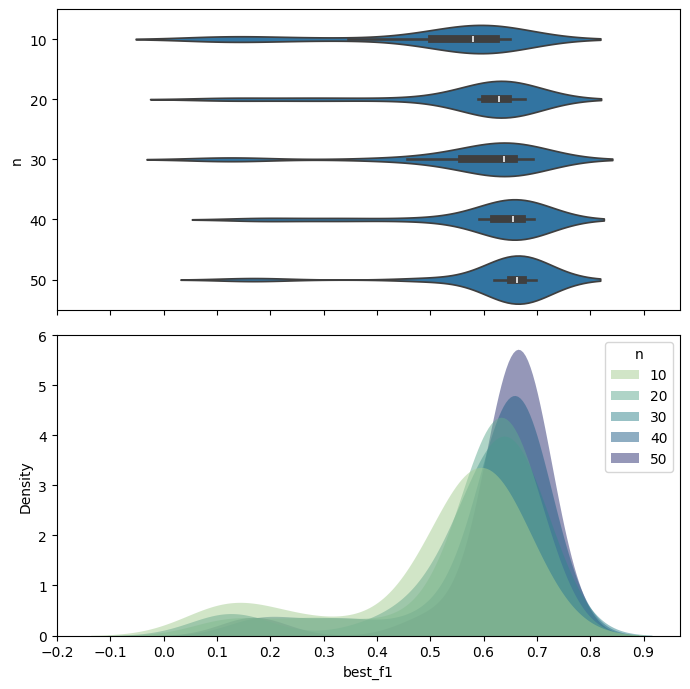

In [123]:
import seaborn as sns
fig, axes = plt.subplots(2, 1, figsize=(7,7), sharex=True)
sns.violinplot(data=df, x='best_f1', y='n', orient='h', ax=axes[0])
sns.kdeplot(data=df, x='best_f1', hue='n', fill=True, common_norm=False, alpha=0.5, palette='crest', linewidth=0, ax=axes[1])
start, end = axes[0].get_xlim()
plt.xticks(np.arange(start.round(1), end, 0.1))
plt.tight_layout()

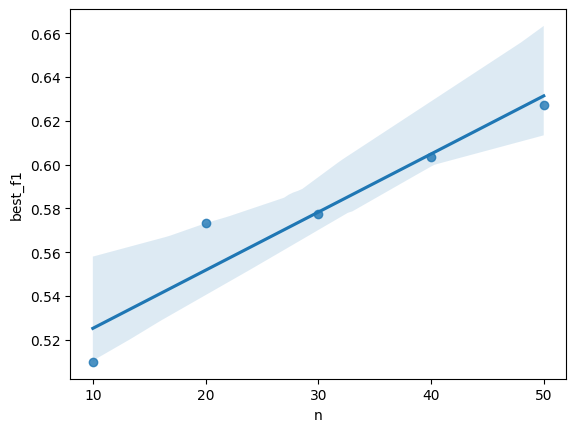

In [124]:
ax = plt.subplot()
dfbyn = df.groupby('n', as_index=False).mean(numeric_only=True)
# sns.scatterplot(data=dfbyn, x='n', y='best_f1', palette='crest', )
sns.regplot(data=dfbyn, x='n', y='best_f1', ax=ax)
# ax.errorbar(
#     dfbyn['n'], 
#     dfbyn['best_f1'], 
#     yerr=df.groupby('n', as_index=False).std(numeric_only=True)['best_f1'], 
#     fmt='o'
# )
ax.set_xticks(range(10, 60, 10));

# Data Augmentation

In [134]:
from torch.utils.data import DataLoader, ConcatDataset, Dataset
from lib.data.datasets import WindowedDatasetWithStrideAndModeOfLabel
from sklearn.model_selection import train_test_split
import math
import os
DATA_DIR = f'{os.path.expanduser("~")}/.delta/nursing_pt'

class NoiseDataset(Dataset):
    def __init__(self, nurse, windowsize=1, stride=1):
        self.windowsize = windowsize
        self.stride = stride
        self.channels = 3
        self.X,self.y = torch.load(f'{DATA_DIR}/{nurse}.pt')
        self.len = math.ceil(len(self.X)/self.stride)
        
        self.X = torch.cat([self.X,torch.zeros(self.windowsize-1,3)])

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        return (
            self.X[(idx*self.stride):(idx*self.stride)+self.windowsize].transpose(0,1),
            self.y[(idx*self.stride):(idx*self.stride)+self.windowsize].mode().values
        )

def load_nursing_noise(nurses='all', winsize=2001, test_size=0.25, batch_size=512, stride=1, split=None):
    not_labeled = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
    unlabled_sessions = set.intersection(set(nurses), not_labeled)
    if unlabled_sessions:
        raise ValueError(f"Session indexes {unlabled_sessions} are not labled")

    if nurses == 'all':
        nurses = list(range(11, 71))

    if stride == 'partition':
        stride = winsize
    
    if test_size == 1:
        dev_idx = nurses
        devloader = DataLoader(dataset=ConcatDataset([NoiseDataset(nurse=idx,windowsize=winsize,stride=stride) for idx in dev_idx]),batch_size=batch_size,shuffle=False)
        return None, devloader
    
    if split:
        train_idx, dev_idx = split
        if set(train_idx).intersection(set(dev_idx)):
            raise ValueError(f"Train and dev indexes overlap")
        if set.intersection(set(train_idx).union(set(dev_idx)), not_labeled):
            raise ValueError(f"Some indexes are not labled")
    else:
        train_idx, dev_idx = train_test_split(nurses, test_size=test_size, random_state=0)
    trainloader = DataLoader(dataset=ConcatDataset([NoiseDataset(nurse=idx,windowsize=winsize,stride=stride) for idx in train_idx]),batch_size=batch_size,shuffle=True)
    devloader = DataLoader(dataset=ConcatDataset([NoiseDataset(nurse=idx,windowsize=winsize,stride=stride) for idx in dev_idx]),batch_size=batch_size,shuffle=False)
    
    return trainloader, devloader

In [66]:
# CONFIG = {
#     'WINDOW_SIZE':2001,
#     'NURSING_STRIDE': 2001 // 16,
#     'BATCH_SIZE': 512,
#     'LEARNING_RATE': 3e-4,
#     'TEST_SIZE': 0.25,
#     'DEVICE': 'cuda:0',
#     'DEPTHI': [],
#     'WIDTHI': [],
#     'VALIDATION': [37, 46, 70, 39, 22, 13]
# }
# while True:
#     d,w,_ = sample_regnet()
#     CONFIG['DEPTHI'] = d
#     CONFIG['WIDTHI'] = w
#     params = sum([p.numel() for p in RegNetv3(CONFIG=CONFIG).parameters()])
#     if params > 5_000_000 and params < 10_000_000:
#         break
# print(d,w,params)
# model = RegNetv3(CONFIG=CONFIG).to(CONFIG['DEVICE'])
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['LEARNING_RATE'])

# n = 50
# nurses = list(set(range(11,71)) - set(CONFIG['VALIDATION']))
# train_nurses = np.random.choice(nurses,n, replace=False)
# nursing_trainloader, nursing_testloader = load_nursing_5_class(
#     split=(train_nurses, CONFIG['VALIDATION']),
#     winsize=CONFIG['WINDOW_SIZE'],
#     batch_size=CONFIG['BATCH_SIZE'],
#     stride=CONFIG['NURSING_STRIDE']
# )
# outdir = 'dev/null/1'
# optimization_loop_multi_class(
#     model,
#     nursing_trainloader,
#     nursing_testloader,
#     criterion,
#     optimizer,
#     epochs=150,
#     patience=30,
#     device=CONFIG['DEVICE'],
#     outdir=outdir,
#     writer=outdir,
#     label=n,
#     config=CONFIG
# )

[1, 2, 8, 9] [16, 48, 144, 432] 5211767


50: Epoch 5: Train Loss: 0.29941: Dev Loss: 0.95248, Dev F1: 0.67216:   4%|▍         | 6/150 [01:14<29:37, 12.35s/it]


KeyboardInterrupt: 